<span style="color: blue; font-size: 24px;">
I. BACKGROUND OF PROJECT
<span>


<span style="color: #1E3A8A; font-size: 14px;">
<strong>The goal of this project </strong> is to empower a media campaign targeting high-intent consumers by scanning the web for health and/or wellness content. <br>
<strong>The Business Objective </strong> is to identify as many health and wellness news articles as possible to place Theragun advertisements next to relevant content. <br>
<strong>The data pipeline </strong> we will build by combining article headlines and descriptions, balancing the dataset to train transformer models, in this scope of project we aim to test between Bert-base-uncased vs. RoBERTa-based. <br>
<strong> Evaluation, conclusion and future work </strong> is to achieving an accuracy above 0.86, selecting the robust binary classifier reliably automates web scanning, maximizing campaign reach on qualified consumers.
</span>

<span style="color: blue; font-size: 24px;">
II. DATA PREPARATION
<span>


## First let's set google colab runtime to use GPU for deep learning


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Sep 20 07:12:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load the data

In [3]:
!pip install -q "transformers<4.40.0" "tf_keras" ktrain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 29.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 39.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 kB 40.0 MB/s eta 0:00:00
ERROR: pip's dependency resolv

In [4]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["USE_TF"] = "1"

In [5]:
import ktrain
print(ktrain.__version__)

/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.13/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.13/dist-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


0.41.4


In [6]:
import pandas as pd
import numpy as np

In [7]:
# UPDATE THE PATH OF YOUR DATAFILE:
data = pd.read_json('/content/drive/MyDrive/Colab Notebooks/supervised learning final project/news_category_trainingdata.json')

## Inspect the data

In [8]:
data.head()

,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26


In [9]:
#checking dataset if matching with category grouping:
data['category'].value_counts()

,count
category,
POLITICS,32739
WELLNESS,17827
ENTERTAINMENT,16058
TRAVEL,9887
STYLE & BEAUTY,9649
PARENTING,8677
HEALTHY LIVING,6694
QUEER VOICES,6314
FOOD & DRINK,6226


<span style="color: #1E3A8A; font-size: 14px;"> We have multi-label of the news, as the target is to predict the new articles to be about Health & Welness or not, we will grouping the articles here into Health & Wellness (~ label 1) vs. Not Health & Wellness (~label 0) - in which the artciles in category WELLNESS & HEALTHY LIVING will be merge into 1, and the rest into 0. <br>
After re-grouping data, we will split it to train/validation set and will proceed the training accordingly.
</span>

## Prepare the data

In [10]:
#copy to new data frame for easy processing without re-importing the whole file:
df = data.copy()

df['text'] = df['headline'].fillna('') + " " + df['short_description'].fillna('')
df['binary_target'] = df['category'].str.contains('WELLNESS|HEALTH', case=False, na=False).astype(int)

#Balance using the group sample have been regrouping on binary_target
df_balanced = df.groupby('binary_target', group_keys=False).sample(n=3000, replace=True, random_state=42).reset_index(drop=True)

#Extract text and binary labels
X = df_balanced['text'].to_numpy()
y = df_balanced['binary_target'].to_numpy()

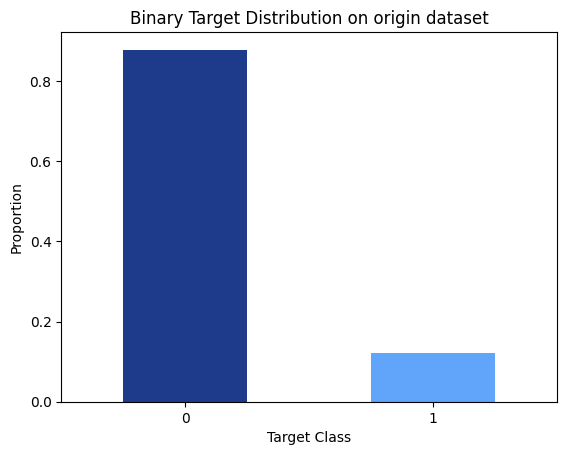

In [11]:
import matplotlib.pyplot as plt
df['binary_target'].value_counts(normalize=True).plot(kind='bar', color=['#1E3A8A', '#60A5FA'])

plt.title('Binary Target Distribution on origin dataset')
plt.xlabel('Target Class')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

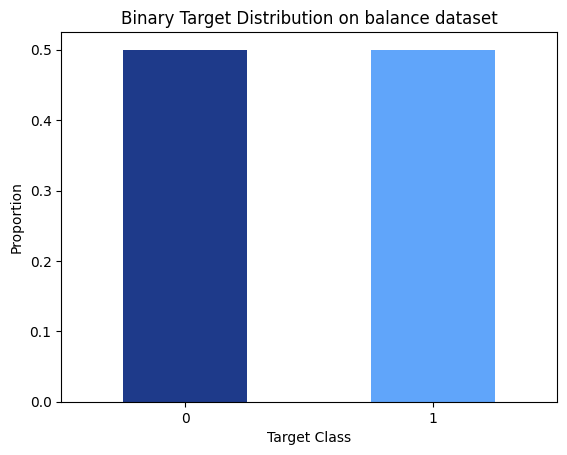

In [12]:
df_balanced['binary_target'].value_counts(normalize=True).plot(kind='bar', color=['#1E3A8A', '#60A5FA'])

plt.title('Binary Target Distribution on balance dataset')
plt.xlabel('Target Class')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

In [13]:
#now we have data properly label and I choose to select 3000 for balance sample
#we then continue to split this sample to 80% train and 20% test:

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict_encoded = {i: weight for i, weight in enumerate(weights)}

<span style="color: blue; font-size: 24px;">
III. MODEL BUIDLING
<span>

<span style="color: #1E3A8A; font-size: 14px;">
we will first build model using ber base uncased: <br>
<strong>standard bert-base-uncased: </strong>  The standard full-size model has 12 transformer layers and roughly 100++ million parameters. <br>
distilbert-base-uncased: A "distilled" (smaller, lighter) version has 6 transformer layers and roughly 60++ million parameters—making it 40% smaller in file size.
<br>
accordingly distilbert-base-uncased runs roughly 60% faster during training and inference compared to standard BERT while requiring less GPU memory.
bert-base-uncased takes longer to train and epoch per epoch because of its deeper architecture and higher parameter count.
<br>
for this initial iteration, i will train on distill version.
</span>

In [14]:
import random
import tensorflow as tf
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_global_seed(42)


# Patch NumPy 2.0+ attribute deprecations for ktrain compatibility
if not hasattr(np, "Inf"):
    np.Inf = np.inf

from ktrain import text

#we will use distilbert-base-uncased to train
MODEL_NAME = 'distilbert-base-uncased'

# Initialize with binary class names [0, 1]
t = text.Transformer(MODEL_NAME, maxlen=128, class_names=[0, 1])
train_data = t.preprocess_train(X_train, y_train)
val_data = t.preprocess_test(X_val, y_val)

model = t.get_classifier()
learner = ktrain.get_learner(model, train_data=train_data, val_data=val_data, batch_size=32)

# Train model
learner.fit_onecycle(2e-5, 3, class_weight=class_weight_dict_encoded)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

preprocessing train...
language: en
train sequence lengths:
	mean : 32
	95percentile : 58
	99percentile : 67


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

<div></div>

Is Multi-Label? False
preprocessing test...
language: en
test sequence lengths:
	mean : 32
	95percentile : 57
	99percentile : 64


<div></div>



begin training using onecycle policy with max lr of 2e-05...
Epoch 1/3
150/150 [==============================] - 90s 500ms/step - loss: 0.5076 - accuracy: 0.7598 - val_loss: 0.3001 - val_accuracy: 0.8808
Epoch 2/3
150/150 [==============================] - 83s 543ms/step - loss: 0.2552 - accuracy: 0.9040 - val_loss: 0.2155 - val_accuracy: 0.9183
Epoch 3/3
150/150 [==============================] - 83s 541ms/step - loss: 0.1487 - accuracy: 0.9485 - val_loss: 0.2229 - val_accuracy: 0.9200


In [15]:
model.summary()

Model: "tf_distil_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_39 (Dropout)        multiple                  0         
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
from sklearn.metrics import classification_report

val_preds = learner.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)

if len(val_data.y.shape) > 1:
    y_true = np.argmax(val_data.y, axis=1)
else:
    y_true = val_data.y

# Generate report for numeric labels 0 and 1
report_dict = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose().round(2)
report_df['support'] = report_df['support'].astype(int)

display(report_df)

38/38 [==============================] - 8s 161ms/step


,precision,recall,f1-score,support
0,0.93,0.90,0.92,600
1,0.91,0.94,0.92,600
accuracy,0.92,0.92,0.92,0
macro avg,0.92,0.92,0.92,1200
weighted avg,0.92,0.92,0.92,1200


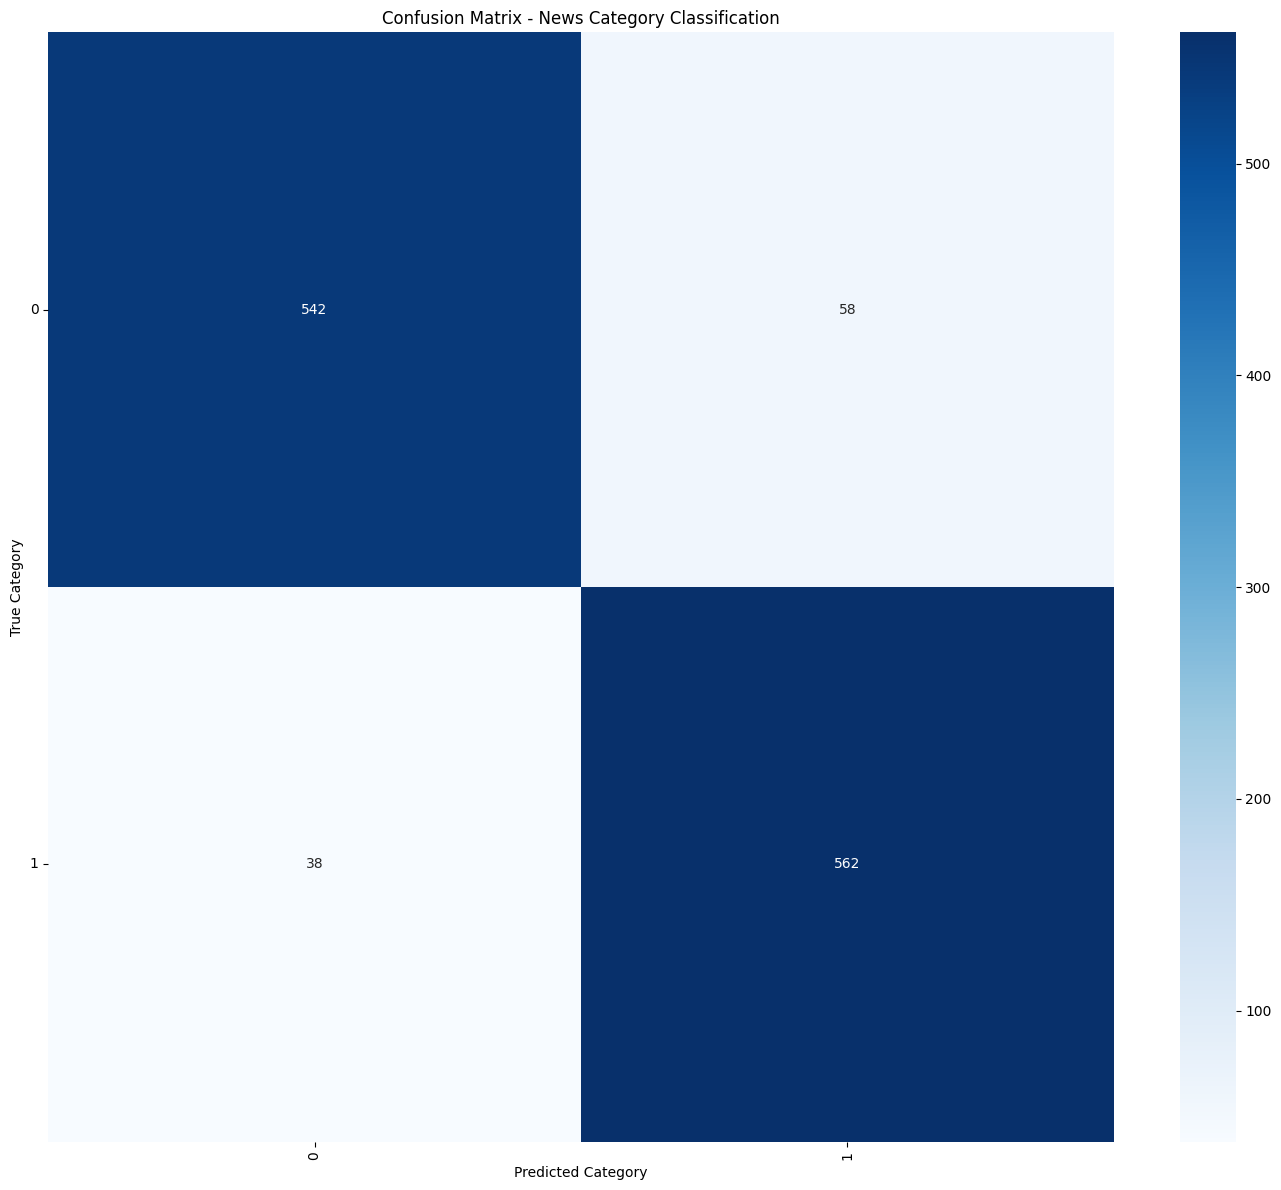

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

class_names = t.get_classes()
#Generate and plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - News Category Classification')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<span style="color: blue; font-size: 24px;">
IV. MODEL EVALUATION & COMPARISON
<span>

<span style="color: #1E3A8A; font-size: 14px;">
as we have accuracy good enough thus we do not need to retry on full - standard bert base uncased, but let's try on roberta-base so we can compare performance between them.

<br>
<strong>BERT: Uses Static Masking. </strong>
 Words are masked once during data preprocessing, meaning the exact same words are masked out every single time the model sees that sentence across all training epochs. It also includes a "Next Sentence Prediction" (NSP) auxiliary task. <br>

<strong>RoBERTa: Uses Dynamic Masking. </strong>
 The masking pattern is regenerated every time a sequence is fed into the model. Over many epochs, the model sees different combinations of masked tokens, making it significantly more robust. RoBERTa also completely removed the NSP task, focusing entirely on masked language modeling.

</span>

In [18]:
import random
import tensorflow as tf
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_global_seed(42)

#Patch NumPy 2.0+ attribute deprecations for ktrain compatibility
if not hasattr(np, "Inf"):
    np.Inf = np.inf

from ktrain import text

# update to roberta model
MODEL_NAME = 'roberta-base'

t = text.Transformer(MODEL_NAME, maxlen=128, class_names=[0, 1])
train_data = t.preprocess_train(X_train, y_train)
val_data = t.preprocess_test(X_val, y_val)

model = t.get_classifier()
learner = ktrain.get_learner(model, train_data=train_data, val_data=val_data, batch_size=32)

# Train model
learner.fit_onecycle(2e-5, 3, class_weight=class_weight_dict_encoded)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

preprocessing train...
language: en
train sequence lengths:
	mean : 32
	95percentile : 58
	99percentile : 67


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

<div></div>

Is Multi-Label? False
preprocessing test...
language: en
test sequence lengths:
	mean : 32
	95percentile : 57
	99percentile : 64


<div></div>



begin training using onecycle policy with max lr of 2e-05...
Epoch 1/3
150/150 [==============================] - 183s 1s/step - loss: 0.4290 - accuracy: 0.7792 - val_loss: 0.2284 - val_accuracy: 0.9175
Epoch 2/3
150/150 [==============================] - 162s 1s/step - loss: 0.2248 - accuracy: 0.9185 - val_loss: 0.1969 - val_accuracy: 0.9300
Epoch 3/3
150/150 [==============================] - 162s 1s/step - loss: 0.1164 - accuracy: 0.9631 - val_loss: 0.2120 - val_accuracy: 0.9275


In [19]:
model.summary()

Model: "tf_roberta_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 roberta (TFRobertaMainLaye  multiple                  124055040 
 r)                                                              
                                                                 
 classifier (TFRobertaClass  multiple                  592130    
 ificationHead)                                                  
                                                                 
Total params: 124647170 (475.49 MB)
Trainable params: 124647170 (475.49 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [20]:
from sklearn.metrics import classification_report

val_preds = learner.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)

if len(val_data.y.shape) > 1:
    y_true = np.argmax(val_data.y, axis=1)
else:
    y_true = val_data.y

# Generate report for numeric labels 0 and 1
report_dict = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose().round(2)
report_df['support'] = report_df['support'].astype(int)

display(report_df)

38/38 [==============================] - 14s 289ms/step


,precision,recall,f1-score,support
0,0.92,0.94,0.93,600
1,0.94,0.92,0.93,600
accuracy,0.93,0.93,0.93,0
macro avg,0.93,0.93,0.93,1200
weighted avg,0.93,0.93,0.93,1200


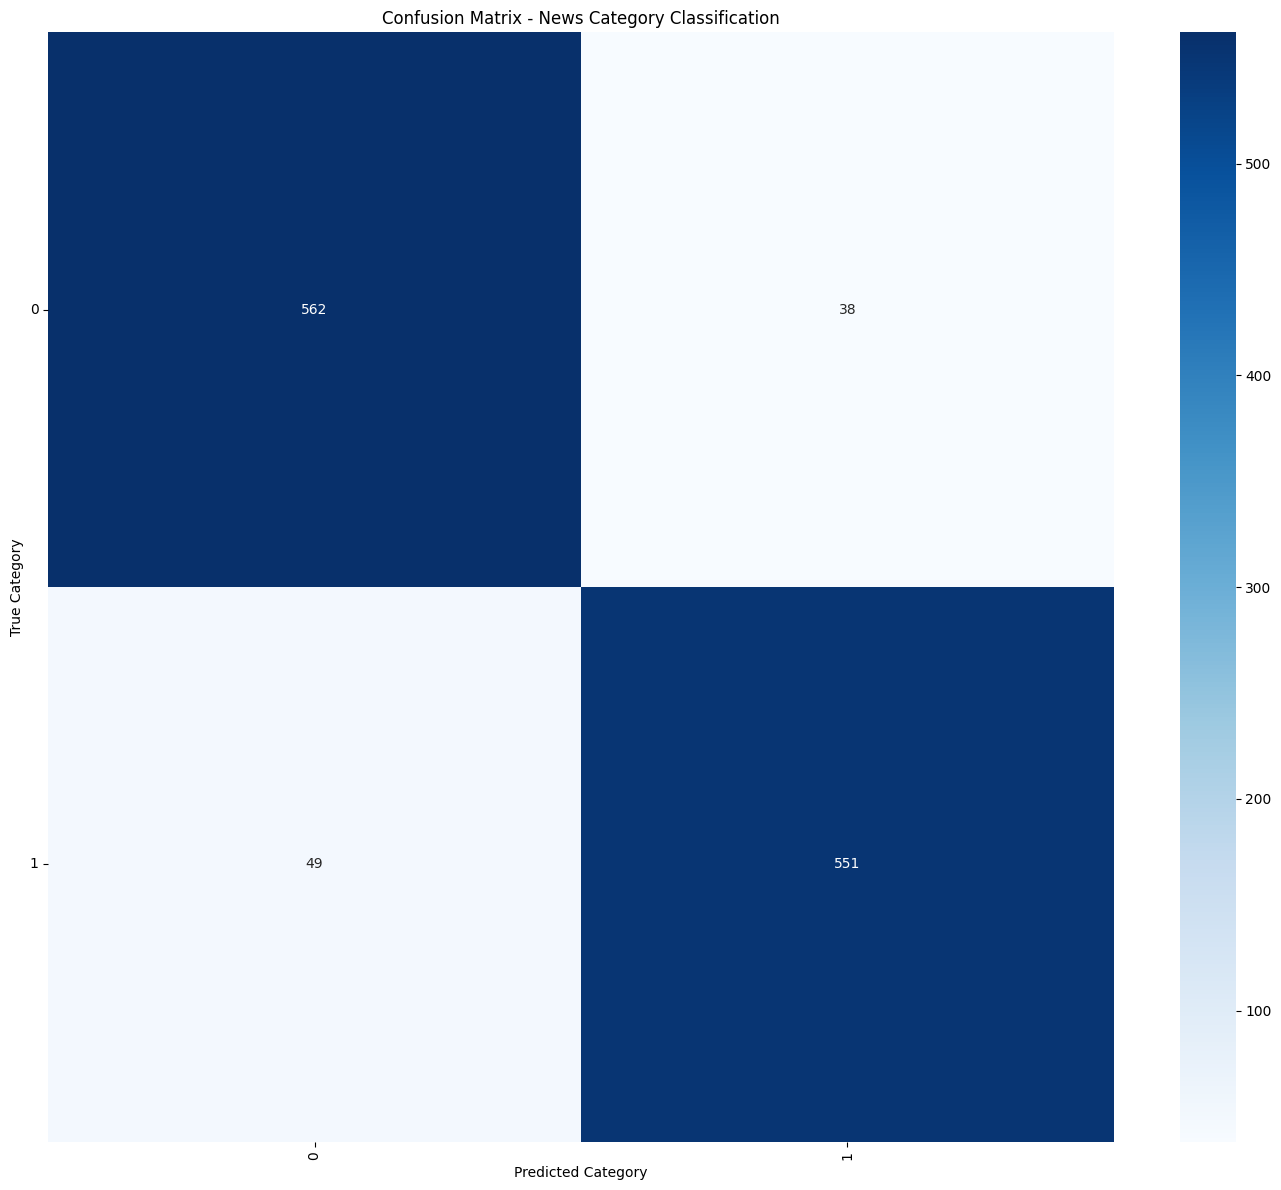

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

class_names = t.get_classes()

#Generate and plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - News Category Classification')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<span style="color: blue; font-size: 24px;">
V. CONCLUSION
<span>

<span style="color: #1E3A8A; font-size: 14px;">

<strong>1) Target exceeded: </strong>
 Both models comfortably surpassed threshold 0.86 accuracy goal, proving the binary pipeline and balancing approach are highly effective. <br>
<strong>2) RoBERTa wins marginally:  </strong>
roberta-base achieves a slightly higher overall accuracy and F1-score (0.93) compared to distilbert-base-uncased (0.92).<br>
<strong>3) Better class balance: </strong>
 RoBERTa displays more uniform metrics across both classes (precision/recall ranging evenly between 0.92 and 0.93). In contrast, DistilBERT shows a slight trade-off, dipping on Class 0 recall (0.90) while spiking on Class 1 recall (0.94).<br>
<strong>4) Recommendation: </strong>
from this quick exploration, we observe RoBERTa is the preferred model base on balanced condition, however for final decision of using which model for deployment, future work suggested to be:<br>
        i) testing stability over various training sample size, and;<br>
       ii) tracking processing time consumption.

</span>

In [2]:
!jupyter nbconvert --to html final_project_HW_submit.ipynb

# from google.colab import files
# files.download('final_project_HW_submit.html')

[NbConvertApp] Converting notebook final_project_HW_submit.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 598267 bytes to final_project_HW_submit.html
